In [1]:
# !pip install thetaflow
# !pip install lifelines
# !pip install seaborn

In [2]:
import warnings
import time

import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import lifelines

import os

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

from scipy.stats import norm, t
from scipy.special import gamma

# import thetaflow as thf
import modelnn2 as thf

2026-03-12 15:52:16.548899: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773341539.047729   22761 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4463 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/natan/codes/thetaflow_method_paper/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1773341539.064911   22761 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4463 MB memory:  -> device: 0, name: NVIDIA GeForc

# The dataset

We will be considering a RNA-sequence count table as input to our neural network. This high dimensional table consists of a $n \times p$ matrix where $n$ is the number of patients and $p$ is the number of genes being studied. Each entry to this table represents the number of times a specific gene appeared in the first tumor cell of a given breast cancer patient up to a variance stabilizing transformation. Because of that transformation, the table we get is properly a continuous data matrix.

With that, considering a neural network, we want to directly map that profile to a Weibull survival time distribution. First of all, we must determine if assuming a proportion of cured individuals is valid or not.

In [3]:
df = pd.read_csv("tcga_brca_count_data.csv")

print("Data dimensions: {}".format(df.shape))
df.head()

Data dimensions: (1094, 28394)


,time,delta,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,...,ENSG00000288600.1,ENSG00000288605.1,ENSG00000288610.1,ENSG00000288611.1,ENSG00000288612.1,ENSG00000288658.1,ENSG00000288663.1,ENSG00000288670.1,ENSG00000288674.1,ENSG00000288675.1
0,652,0,9.236898,4.058348,10.964864,10.513271,8.862942,10.466286,11.631919,10.977731,...,4.332030,3.064062,4.058348,3.645597,5.313244,4.205053,6.229222,8.733492,4.444878,5.964324
1,1246,0,10.223195,5.281296,12.347547,10.076926,9.089810,8.651819,10.387053,12.466915,...,4.224119,3.971985,3.064062,3.593961,6.253292,3.809357,4.665666,7.980932,3.809357,5.908364
2,90,0,10.449917,4.484088,10.929133,10.244865,8.197153,7.820926,11.941674,11.399724,...,4.408410,4.484088,3.064062,4.140584,4.031214,3.064062,4.238209,8.172959,3.064062,5.537024
3,1471,0,10.943582,4.280462,10.949728,10.733436,8.308763,9.013656,11.545420,11.056104,...,4.606796,4.066634,3.779970,3.064062,4.859536,3.064062,5.846777,8.365070,3.779970,6.262540
4,172,1,9.740298,4.469670,11.298822,10.700813,8.708184,7.809997,11.841186,11.968232,...,3.549063,3.064062,3.064062,3.896475,5.939797,5.893332,4.783704,9.547732,4.226009,5.662420


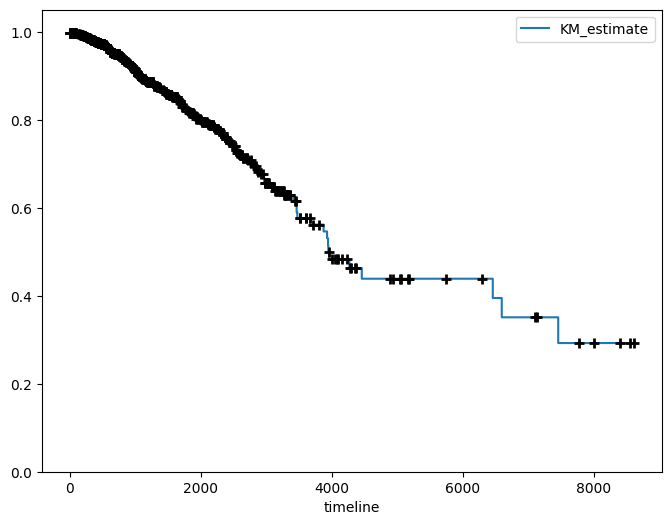

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df["time"], df["delta"])
km.plot(ax = ax, ci_show = False, show_censors = True, censor_styles={
    'ms': 7,      # marker size
    'marker': '+', # marker shape
    'mew': 2,       # marker edge width
    'markeredgecolor': 'black',
    'zorder': 5
})

ax.set_ylim(0,1.05)

plt.show()

As we can see, data suggests there should exist a fraction of patients that are immune to the event of death, given that for higher times, the Kaplan-Meier curve seems to stabilize at some point greater than zero. In fact, multiple censorships fall in this final value, suggesting a stronger evidence than just random fluctuations would cause data to be like this.

To start our model, let us consider a simple promotion time cure model with a Poisson distributed latent discrete frailty variable. For the base distribution we will be considering a Weibull distribution.

We will also fit a standard Weibull distribution without assuming a cured fraction, so we can compare both models in terms of quantilic residuals for example. For now, we expect that only between both these models, the one that accounts for a cured fraction should be best suited for this particular dataset.

# The models definitions

### Naive Weibull distribution - Both parameters nn

In [5]:
# 1. Bounded Shape Parameter (rho)
@tf.function(reduce_retracing=True)
def rho_link(x):
    # Caps the shape parameter at a maximum of 10.0 to prevent tf.pow() explosions
    return 10.0 * tf.math.sigmoid(x) + 1e-4

@tf.function(reduce_retracing=True)
def rho_link_inv(x):
    x_shifted = x - 1e-4
    return tf.math.log(x_shifted / (10.0 - x_shifted))

# 2. Bounded Scale Parameter (lam)
@tf.function(reduce_retracing=True)
def lam_link(x):
    # Determine what your maximum expected time 't' is. 
    # Let's assume 1000 is a safe upper bound for your scale.
    return 1000.0 * tf.math.sigmoid(x) + 1e-4

@tf.function(reduce_retracing=True)
def lam_link_inv(x):
    x_shifted = x - 1e-4
    return tf.math.log(x_shifted / (1000.0 - x_shifted))

weibull_parameters = {
    "lam": {"link": lam_link, "link_inv": lam_link_inv, "par_type": "nn", "shape": 1, "init": 1.0}, # scale
    "rho": {"link": rho_link, "link_inv": rho_link_inv, "par_type": "nn", "shape": 1, "init": 1.0} # shape
}

# POSSIBLY I SHOULD BE CONSIDERING RHO TO BE A GLOBAL CONSTANT!!!
# weibull_parameters = {
#     "lam": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0}, # scale
#     "rho": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0} # shape
# }

def weibull_loglikelihood_loss(model, nn_output, data):
    # Unpack the tuple to include the censoring indicator
    X, y, delta = data
    
    # Extract the strictly positive parameters mapped by the neural network
    lam = model.get_variable("lam", nn_output)
    rho = model.get_variable("rho", nn_output)
    
    # log-hazard component
    log_hazard = tf.math.log(rho) + (rho - 1.0) * tf.math.log(y) - rho * tf.math.log(lam)
    # cumulative hazard
    cum_hazard = tf.math.pow(y / lam, rho)
    
    # log-likelihood
    loglik = tf.reduce_sum( delta * log_hazard - cum_hazard )
    
    # Return the negative log-likelihood
    return -loglik

def weibull_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    
    # ----- Elastic Net Regularization -----
    # Crucial because p >> n (~60,000 genes vs ~1,000 patients).
    # L1: LASSO Sparsity - feature selection for genes
    # L2: Highly correlated gene clusters, which may lead to multicolinearity problems
    # elastic_net = regularizers.L1L2(l1 = 1.0e-4, l2 = 1.0e-4)
    lasso = tf.keras.regularizers.L1(
        l1 = 0.1
    )
    
    # ----- Compressor layer -----
    # Funnels ~60k normalized gene inputs to a 128 latent space
    model.dense1 = layers.Dense(
        units = 128, 
        activation = "gelu", 
        kernel_initializer = initializer, 
        kernel_regularizer = lasso,
        dtype = tf.float32, 
        name = "gene_compressor"
    )
    
    # ----- Dropout Layer -----
    # Prevents the network from memorizing the small number of patients.
    model.dropout = layers.Dropout(rate = 0.5, seed = seed)

    # ----- Hidden dense layer -----
    model.dense2 = layers.Dense(
        units = 32, 
        activation = "gelu", 
        kernel_initializer = initializer, 
        dtype = tf.float32, 
        name = "latent_representation"
    )

    # ----- Output layer (Weibull parameters) -----
    # 2 outputs:
    # - shape parameter rho
    # - scale parameter lambda
    model.output_layer = layers.Dense(
        units = 2, 
        activation = None,
        kernel_initializer = initializers.Zeros(),
        dtype = tf.float32, 
        name = "weibull_params"
    )
    
def weibull_network_call(model, x_input, training = False):
    # x_input shape: (batch_size, p_genes)
    x = model.dense1(x_input)
    # Dropout is typically only applied during the training phase
    x = model.dropout(x, training = training)
    x = model.dense2(x)
    return model.output_layer(x)

def weibull_network_call_nolast(model, x_input):
    # Pass through the first dense layer
    x = model.dense1(x_input)
    
    # Explicitly turn OFF dropout. 
    # This ensures deterministic feature extraction for the LLLA covariance.
    x = model.dropout(x, training = False) 
    
    # Pass through the final hidden layer
    x = model.dense2(x)
    
    # Return the deterministic latent representation phi(x)
    return x

In [6]:
from sklearn.preprocessing import StandardScaler

X = df.iloc[:,2:].to_numpy()

# Standardize X so every feature has mean=0 and variance=1
scaler = StandardScaler()
X = scaler.fit_transform(X)
# X = tf.cast(X, dtype = tf.float32)

# y = tf.cast( df.iloc[:,0].to_numpy()/365, dtype = tf.float32 )
y = df.iloc[:,0].to_numpy()/365
# delta = tf.cast( df.iloc[:,1].to_numpy(), dtype = tf.float32 )
delta = df.iloc[:,1].to_numpy()
data = [tf.constant(y, shape = (len(y), 1), dtype = tf.float32), tf.constant(delta, shape = (len(delta), 1), dtype = tf.float32)]

In [42]:
with tf.device("/GPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    weibull_model = thf.ModelNN(weibull_parameters, weibull_loglikelihood_loss,
                                weibull_neural_network, weibull_network_call,
                                weibull_network_call_nolast, input_dim = (None, X.shape[1]), seed = 10)
    
    weibull_lam_before_pretrain = weibull_model.predict(X)["lam"].numpy().flatten()
    weibull_rho_before_pretrain = weibull_model.predict(X)["rho"].numpy().flatten()
    
    weibull_model.pre_train_model(X, data,
                                  epochs = 500, shuffle = True,
                                  verbose = 1, track_time = True)

    weibull_lam_after_pretrain = weibull_model.predict(X)["lam"].numpy().flatten()
    weibull_rho_after_pretrain = weibull_model.predict(X)["rho"].numpy().flatten()

    weibull_model.train_model(X, data,
                              epochs = 15000, shuffle = True, metrics_update_freq = 50,
                              fine_tune = False,
                              get_covariances = True,
                              validation = False, val_prop = 0.2,
                              optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                              # optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                              train_batch_size = None, val_batch_size = None,
                              buffer_size = 4096, gradient_accumulation_steps = None,
                              early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                              reduce_lr = True, reduce_lr_warmup = 10,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                              reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
                              deterministic = True,
                              verbose = 1, print_freq = 50)

    weibull_lam_after_train = weibull_model.predict(X)["lam"].numpy().flatten()
    weibull_rho_after_train = weibull_model.predict(X)["rho"].numpy().flatten()

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 9550 / 15000 ]  | Loss:  66214.8125 | Param Dist:  23.8738766 | Independent Learning rate:  0.01 | Network Learning rate:  1e-05 | [Speed tracking disabled for determinism]   Updating nn learning rate tf.Tensor(0.001, shape=(), dtype=float32)

Done.
Extracting covariance structure.
Done.
Optimization finished in 177.068 seconds.


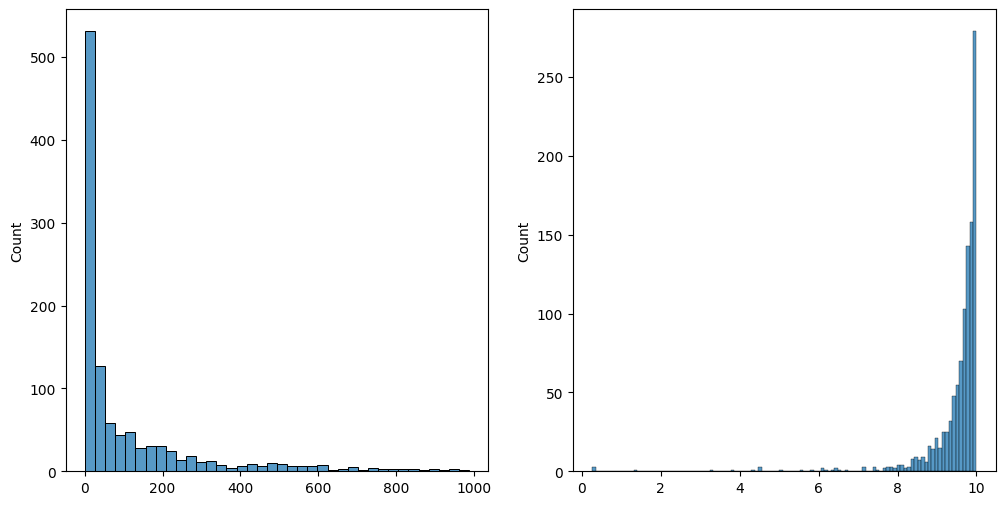

In [43]:
nn_output = weibull_model(X, training = False)

lam_X = weibull_model.get_variable("lam", nn_output)
rho_X = weibull_model.get_variable("rho", nn_output)
    
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

sns.histplot(x = lam_X.numpy().flatten(), ax = ax[0])
sns.histplot(x = rho_X.numpy().flatten(), ax = ax[1])

plt.show()

Look at how even bounding the parameters using the link functions, the shape parameter is still being maximized by the model. That happens mostly due to overfitting. Essentially, by increasing $\rho$ the hazard function tends to a Dirac delta. Essentially, because each individual has its parameters free to vary and we have a high dimensional dataset, the model may be trying to fit each patient as a Dirac delta observation, as if they had a 100\% of failure right at the time they died. That direction indeed decreases the loss function, as we would be following an overfitted degenerate case.

Therefore, we need to remove some flexibility of the model. One simple solution is to consider $\rho$ to be a constant, global parameter. We will be doing that in the next section.

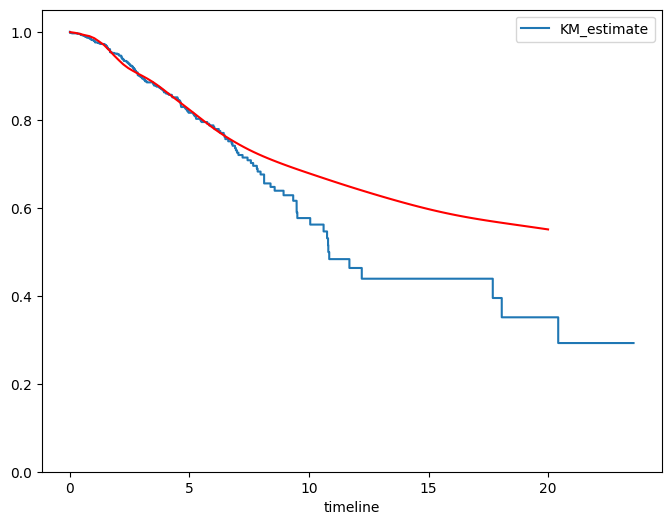

In [45]:
# lam_X = tf.ones_like(lam_X) * 17.15514
# rho_X = 1.299237

ts = tf.constant(np.linspace(0.01, 20, 100), dtype = tf.float32)

S_ts = tf.math.exp( -(ts / lam_X)**rho_X )
S_ts_avg = tf.reduce_mean( S_ts, axis = 0 )

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df["time"]/365, df["delta"])
km.plot(ax = ax, ci_show = False, show_censors = False, censor_styles={
    'ms': 7,      # marker size
    'marker': '+', # marker shape
    'mew': 2,       # marker edge width
    'markeredgecolor': 'black',
    'zorder': 5
})
# sns.lineplot(x = ts, y = S_ts_avg, color = "red")
ax.plot(ts, S_ts_avg, color = "red")

ax.set_ylim(0,1.05)

plt.show()

# tf.print("-> LAST SAFE lam (min | max):", tf.reduce_min(lam_batch), "|", tf.reduce_max(lam_batch))
# tf.print("-> LAST SAFE rho (min | max):", tf.reduce_min(rho_batch), "|", tf.reduce_max(rho_batch))

In [14]:
weibull_model.get_weights()

[array([[-3.89697496e-04, -3.54447693e-05,  1.52457404e-04, ...,
          1.38949152e-04, -9.13916738e-04, -1.02488382e-04],
        [ 2.10482322e-04,  2.65104289e-04,  1.01405658e-05, ...,
          4.10250388e-04, -2.81404966e-04, -1.68210259e-04],
        [ 3.12146549e-05, -1.13459537e-03,  1.07126703e-04, ...,
         -8.10204219e-05, -4.47259408e-05, -1.08559834e-04],
        ...,
        [ 7.51187399e-05, -7.79571885e-04,  2.06416171e-05, ...,
         -6.79593417e-04, -2.28881545e-05,  1.16842039e-05],
        [ 1.51938555e-04,  3.10600481e-05, -7.96750028e-05, ...,
         -4.46185906e-04, -1.05606625e-03, -9.90673550e-04],
        [ 6.02767512e-04, -4.23473793e-05, -1.56552687e-05, ...,
          9.99508891e-04,  5.73494332e-03, -1.05459570e-04]],
       shape=(28392, 128), dtype=float32),
 array([ 0.13492155,  0.06134505,  0.3426622 ,  0.38032842, -0.12302227,
        -0.00348357, -0.07114053,  0.16899133,  0.2526816 ,  0.2798311 ,
         0.29578874,  0.25278535,  0.2889

In [37]:
W1 = weibull_model.dense1.get_weights()[0]

# 2. Calculate the Importance Score for each gene
# We sum the absolute values of the outgoing weights for each gene across all 128 nodes
gene_importance = np.sum(np.abs(W1), axis=1)

# 3. Define a "practically zero" threshold
# Since Adam doesn't hit exact 0, we treat anything smaller than 1e-4 as dead.
threshold = 1e-1

# 4. Find the active vs. dead genes
active_genes_mask = gene_importance > threshold
dead_genes_mask = gene_importance <= threshold

num_active = np.sum(active_genes_mask)
num_dead = np.sum(dead_genes_mask)

print(f"Total Genes: {len(gene_importance)}")
print(f"Active Genes (I_j > {threshold}): {num_active}")
print(f"Dead Genes (crushed by Elastic Net): {num_dead}")

Total Genes: 28392
Active Genes (I_j > 0.1): 5547
Dead Genes (crushed by Elastic Net): 22845


<Axes: ylabel='Count'>

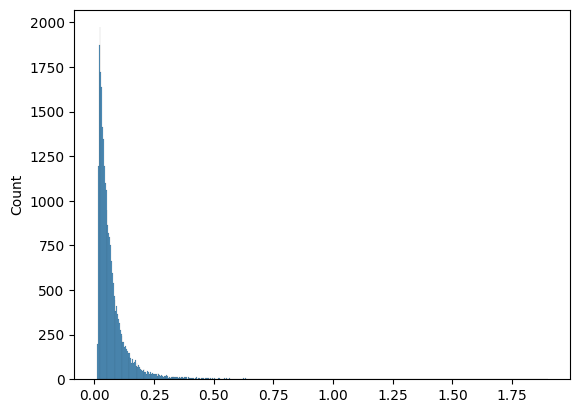

In [39]:
sns.histplot( gene_importance )

### Using K-fold hyperparameter grid search

In [21]:
# X[train_idx]

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import initializers, regularizers, layers, optimizers
from sklearn.model_selection import KFold

# 1. Factory Function to inject dynamic L1 penalties
def build_network_with_l1(l1_val):
    def weibull_neural_network_cv(model, seed = 10):
        initializer = initializers.GlorotNormal(seed = seed)
        
        # Using pure LASSO as requested
        lasso = regularizers.L1(l1 = l1_val)

        model.dense1 = layers.Dense(
            units = 128, activation = "gelu", 
            kernel_initializer = initializer, kernel_regularizer = lasso,
            dtype = tf.float32, name = "gene_compressor"
        )
        
        model.dropout = layers.Dropout(rate=0.5, seed=seed)
        
        model.dense2 = layers.Dense(
            units = 32, activation = "gelu", 
            kernel_initializer = initializer, 
            dtype = tf.float32, name = "latent_representation"
        )

        # Maintained the safe zero-initialization for the exponential/softplus links
        model.output_layer = layers.Dense(
            units = 2, activation = None,
            kernel_initializer = initializers.Zeros(),
            dtype = tf.float32, name = "weibull_params"
        )
    return weibull_neural_network_cv

# 2. Setup the Cross-Validation Grid
# l1_grid = [1e-4, 1e-3, 1e-2, 1e-1]
l1_grid = [1e-2, 1e-1]
k_folds = 5
kf = KFold(n_splits = k_folds, shuffle = True, random_state = 42)

cv_results = {}

for l1 in l1_grid:
    print(f"\n======================================")
    print(f"Testing LASSO L1 Penalty: {l1}")
    print(f"======================================")
    
    fold_losses = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"--- Fold {fold + 1}/{k_folds} ---")
        
        # Split the data arrays
        X_train_cv, X_val_cv = X[train_idx], X[val_idx]
        y_train_cv, y_val_cv = y[train_idx], y[val_idx]
        delta_train_cv, delta_val_cv = tf.cast( delta[train_idx], dtype = tf.float32 ), tf.cast( delta[val_idx], dtype = tf.float32 )
        
        data_train = [tf.constant( y_train_cv, shape = (len(y_train_cv), 1), dtype = tf.float32 ), tf.constant( delta_train_cv, shape = (len(delta_train_cv), 1), dtype = tf.float32 )]
        data_val = [tf.constant( y_val_cv, shape = (len(y_val_cv), 1), dtype = tf.float32 ), tf.constant( delta_val_cv, shape = (len(delta_val_cv), 1), dtype = tf.float32 )]
        
        # Instantiate a FRESH model for each fold to avoid weight leakage
        cv_model = thf.ModelNN(
            weibull_parameters, 
            weibull_loglikelihood_loss,
            build_network_with_l1(l1), # Injecting the specific L1 value
            weibull_network_call,
            weibull_network_call_nolast, 
            input_dim = (None, X_train_cv.shape[1]), 
            seed = 10
        )

        cv_model.pre_train_model(X_train_cv, data_train, epochs = 1, shuffle = True)
        
        # Train the model (consider fewer epochs to keep CV computationally feasible)
        cv_model.train_model(
            X_train_cv, data_train,
            epochs = 1500, shuffle=True, metrics_update_freq = 50,
            fine_tune = False,
            validation = False,
            optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
            early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
            reduce_lr = True, reduce_lr_warmup = 10,
            reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
            reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
            deterministic = True, get_covariances = False,
            verbose = 1 # Suppressing epoch spam during CV
        )
        
        # Calculate validation loss
        # Pass the validation data through the network and custom loss function
        val_nn_output = cv_model(X_val_cv)
        val_loss_tensor = weibull_loglikelihood_loss(cv_model, val_nn_output, [X_val_cv] + data_val)
        
        # Normalize the loss by the number of patients in the validation fold 
        # so folds with slightly different sizes are comparable
        val_loss = val_loss_tensor.numpy() / len(X_val_cv)
        fold_losses.append(val_loss)
        
        # Quick check of sparsity for this fold
        W1 = cv_model.dense1.get_weights()[0]
        active_genes = np.sum(np.sum(np.abs(W1), axis=1) > 1e-4)
        print(f"Fold {fold+1} Validation Loss: {val_loss:.4f} | Active Genes: {active_genes}")

    # Average the loss across all 5 folds
    avg_cv_loss = np.mean(fold_losses)
    cv_results[l1] = avg_cv_loss
    print(f"\n>>> Average CV Loss for L1={l1}: {avg_cv_loss:.4f}")

# 3. Identify the optimal hyperparameter
best_l1 = min(cv_results, key = cv_results.get)
print(f"\nOptimal LASSO L1 Penalty derived from Cross-Validation: {best_l1}")


Testing LASSO L1 Penalty: 0.01
--- Fold 1/5 ---
GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1400 / 1500 ]  | Loss:  19033.1406 | Param Dist:  6.43671465 | Independent Learning rate:  0.001 | Network Learning rate:  0.0005 | [Speed tracking disabled for determinism]   Updating nn learning rate tf.Tensor(0.001, shape=(), dtype=float32)

Done.
Optimization finished in 30.392 seconds.
Fold 1 Validation Loss: 40.6627 | Active Genes: 28392
--- Fold 2/5 ---
GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1400 / 1500 ]  | Loss:  14681.9453 | Param Dist:  1.96295547 | Independent Learning rate:  0.001 | Network Learning rate:  0.0005 | [Speed tracking disabled for determinism]   Updating nn learning rate tf.Tensor(0.001, sha

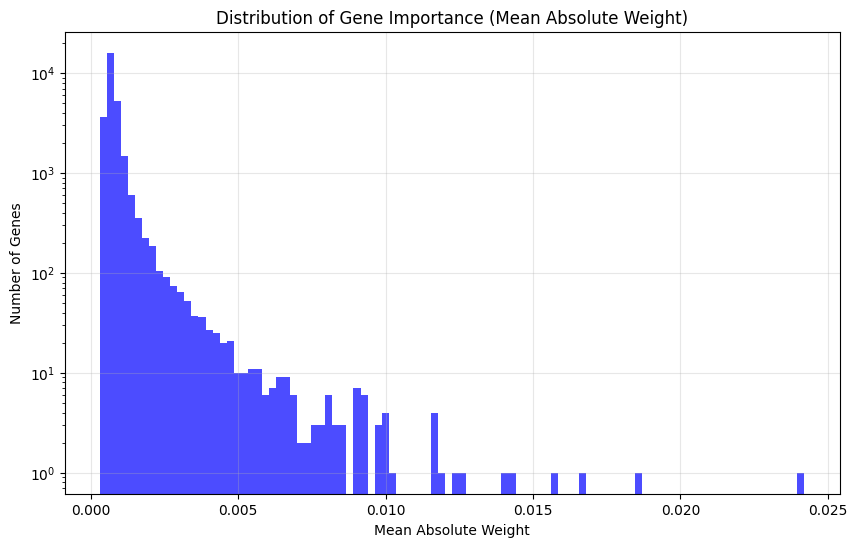

In [10]:
import matplotlib.pyplot as plt

# Calculate the mean absolute weight per gene (instead of the sum)
gene_importance_mean = np.mean(np.abs(W1), axis=1)

# Plot a histogram to see the distribution
plt.figure(figsize=(10, 6))
plt.hist(gene_importance_mean, bins=100, color='blue', alpha=0.7)
plt.title("Distribution of Gene Importance (Mean Absolute Weight)")
plt.xlabel("Mean Absolute Weight")
plt.ylabel("Number of Genes")
plt.yscale('log') # Log scale helps see the active genes spreading to the right
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
cv_results

{0.01: np.float32(1182.0802), 0.1: np.float32(17.334335)}

In [46]:
fold_losses

[np.float32(102.25493),
 np.float32(7.8521543),
 np.float32(37283.996),
 np.float32(39.954857),
 np.float32(127.96002)]

### Naive Weibull distribution - only $\lambda$ as nn

In [25]:
# 2. Bounded Scale Parameter (lam)
@tf.function(reduce_retracing=True)
def lam_link(x):
    # Determine what your maximum expected time 't' is. 
    # Let's assume 1000 is a safe upper bound for your scale.
    return 1000.0 * tf.math.sigmoid(x) + 1e-4

@tf.function(reduce_retracing=True)
def lam_link_inv(x):
    x_shifted = x - 1e-4
    return tf.math.log(x_shifted / (1000.0 - x_shifted))

weibull_parameters = {
    "lam": {"link": lam_link, "link_inv": lam_link_inv, "par_type": "nn", "shape": 1, "init": 1.0}, # scale
    "rho": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0} # shape
}

def weibull_loglikelihood_loss(model, nn_output, data):
    # Unpack the tuple to include the censoring indicator
    X, y, delta = data
    
    # Extract the strictly positive parameters mapped by the neural network
    lam = model.get_variable("lam", nn_output)
    rho = model.get_variable("rho")
    
    # log-hazard component
    log_hazard = tf.math.log(rho) + (rho - 1.0) * tf.math.log(y) - rho * tf.math.log(lam)
    # cumulative hazard
    cum_hazard = tf.math.pow(y / lam, rho)
    
    # log-likelihood
    loglik = tf.reduce_sum( delta * log_hazard - cum_hazard )
    
    # Return the negative log-likelihood
    return -loglik

def weibull_neural_network(model, seed=10):
    initializer = initializers.GlorotNormal(seed=seed)
    
    lasso = tf.keras.regularizers.L1(
        l1 = 0.1
    )
    
    model.dense1 = layers.Dense(
        units = 128, activation = "gelu", 
        kernel_initializer = initializer,
        kernel_regularizer = lasso,
        use_bias = True,
        dtype = tf.float32, name = "gene_compressor"
    )
    
    model.dropout = layers.Dropout(rate=0.5, seed=seed)
    
    model.dense2 = layers.Dense(
        units=32, activation="gelu", 
        kernel_initializer=initializer, 
        dtype=tf.float32, name="latent_representation"
    )

    model.output_layer = layers.Dense(
        units=1, activation=None,
        kernel_initializer=initializers.Zeros(), # Keep the safe initialization!
        dtype=tf.float32, name="weibull_lambda_param"
    )    

def weibull_network_call(model, x_input, training = False):
    # x_input shape: (batch_size, p_genes)
    x = model.dense1(x_input)
    # Dropout is typically only applied during the training phase
    x = model.dropout(x, training = training)
    x = model.dense2(x)
    return model.output_layer(x)

def weibull_network_call_nolast(model, x_input):
    # Pass through the first dense layer
    x = model.dense1(x_input)
    x = model.dropout(x, training = False) 
    x = model.dense2(x)
    return x

In [26]:
with tf.device("/GPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    weibull_model = thf.ModelNN(weibull_parameters, weibull_loglikelihood_loss,
                                weibull_neural_network, weibull_network_call,
                                weibull_network_call_nolast, input_dim = (None, X.shape[1]), seed = 10)
    
    weibull_lam_before_pretrain = weibull_model.predict(X)["lam"].numpy().flatten()
    weibull_rho_before_pretrain = weibull_model.predict("rho")
    
    weibull_model.pre_train_model(X, data,
                                  epochs = 500, shuffle = True,
                                  verbose = 1, track_time = True)

    weibull_lam_after_pretrain = weibull_model.predict(X)["lam"].numpy().flatten()
    weibull_rho_after_pretrain = weibull_model.predict("rho")

    weibull_model.train_model(X, data,
                              epochs = 15000, shuffle = True, metrics_update_freq = 50,
                              fine_tune = False,
                              get_covariances = True,
                              validation = False, val_prop = 0.2,
                              optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                              # optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                              train_batch_size = None, val_batch_size = None,
                              buffer_size = 4096, gradient_accumulation_steps = None,
                              early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                              reduce_lr = True, reduce_lr_warmup = 10,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                              reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
                              deterministic = True,
                              verbose = 1, print_freq = 50)

    weibull_lam_after_train = weibull_model.predict(X)["lam"].numpy().flatten()
    weibull_rho_after_train = weibull_model.predict("rho")

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 14950 / 15000 ]  | Loss:  19377.0215 | Param Dist:  5.66427755 | Independent Learning rate:  3.90625e-05 | Network Learning rate:  3.90625e-05 | [Speed tracking disabled for determinism]   Updating nn learning rate tf.Tensor(0.01, shape=(), dtype=float32)

Done.
Extracting covariance structure.
Done.
Optimization finished in 277.963 seconds.


In [27]:
nn_output = weibull_model(X, training = False)
lam_X = weibull_model.predict(X)["lam"]
rho_X = weibull_model.predict("rho")

In [31]:
rho_X

array([6.2444663], dtype=float32)

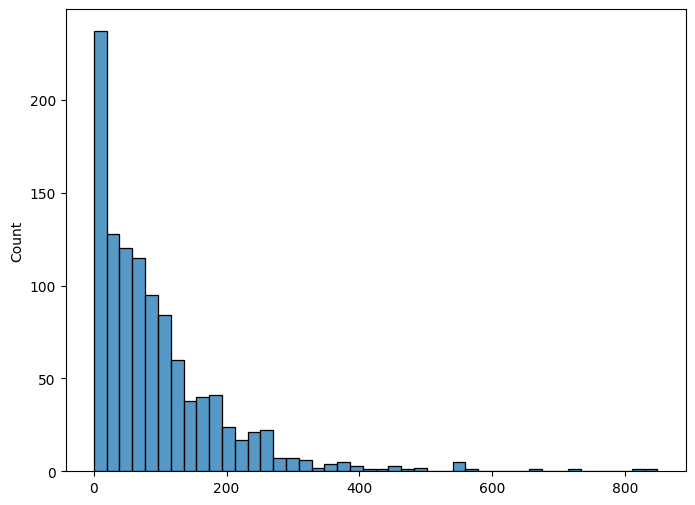

In [29]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.histplot(x = lam_X.numpy().flatten(), ax = ax)

plt.show()

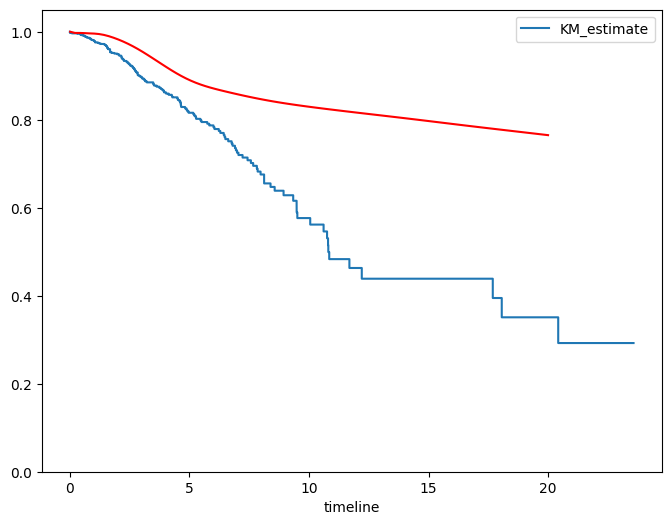

In [30]:
# lam_X = tf.ones_like(lam_X) * 17.15514
# rho_X = 1.299237

ts = tf.constant(np.linspace(0.01, 20, 100), dtype = tf.float32)

S_ts = tf.math.exp( -(ts / lam_X)**rho_X )
S_ts_avg = tf.reduce_mean( S_ts, axis = 0 )

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df["time"]/365, df["delta"])
km.plot(ax = ax, ci_show = False, show_censors = False, censor_styles={
    'ms': 7,      # marker size
    'marker': '+', # marker shape
    'mew': 2,       # marker edge width
    'markeredgecolor': 'black',
    'zorder': 5
})
# sns.lineplot(x = ts, y = S_ts_avg, color = "red")
ax.plot(ts, S_ts_avg, color = "red")

ax.set_ylim(0,1.05)

plt.show()

# tf.print("-> LAST SAFE lam (min | max):", tf.reduce_min(lam_batch), "|", tf.reduce_max(lam_batch))
# tf.print("-> LAST SAFE rho (min | max):", tf.reduce_min(rho_batch), "|", tf.reduce_max(rho_batch))

### Promotion time cure model with Poisson and Weibull

In [51]:
# 2. Bounded Scale Parameter (lam)
@tf.function(reduce_retracing=True)
def theta_link(x):
    # Determine what your maximum expected time 't' is. 
    # Let's assume 1000 is a safe upper bound for your scale.
    return 200.0 * tf.math.sigmoid(x) + 1e-4

@tf.function(reduce_retracing=True)
def theta_link_inv(x):
    x_shifted = x - 1e-4
    return tf.math.log(x_shifted / (200.0 - x_shifted))

@tf.function(reduce_retracing=True)
def lam_link(x):
    # Determine what your maximum expected time 't' is. 
    # Let's assume 1000 is a safe upper bound for your scale.
    return 100.0 * tf.math.sigmoid(x) + 1e-4

@tf.function(reduce_retracing=True)
def lam_link_inv(x):
    x_shifted = x - 1e-4
    return tf.math.log(x_shifted / (100.0 - x_shifted))

@tf.function(reduce_retracing=True)
def rho_link(x):
    # Determine what your maximum expected time 't' is. 
    # Let's assume 1000 is a safe upper bound for your scale.
    return 10.0 * tf.math.sigmoid(x) + 1e-4

@tf.function(reduce_retracing=True)
def rho_link_inv(x):
    x_shifted = x - 1e-4
    return tf.math.log(x_shifted / (10.0 - x_shifted))

# promotion_cure_parameters = {
#     "theta": {"link": theta_link, "link_inv": theta_link_inv, "par_type": "nn", "shape": 1, "init": 3.0},
#     "lam": {"link": lam_link, "link_inv": lam_link_inv, "par_type": "independent", "shape": 1, "init": 1.0}, # scale
#     "rho": {"link": rho_link, "link_inv": rho_link_inv, "par_type": "independent", "shape": 1, "init": 1.0} # shape
# }
promotion_cure_parameters = {
    "theta": {"link": theta_link, "link_inv": theta_link_inv, "par_type": "nn", "shape": 1, "init": 3.0},
    "lam": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0}, # scale
    "rho": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0} # shape
}

def promotion_cure_loglikelihood_loss(model, nn_output, data):
    X, y, delta = data
    
    theta = model.get_variable("theta", nn_output)
    lam = model.get_variable("lam")
    rho = model.get_variable("rho")

    F0 = 1 - tf.math.exp( -(y / lam)**rho )
    log_f0 = tf.math.log(rho) + (rho-1) * tf.math.log(y) - rho * tf.math.log(lam) - (y / lam)**rho
    
    loglik = tf.reduce_sum( delta*( tf.math.log(theta) + log_f0 ) - theta*F0 )
    
    return -loglik

def promotion_cure_neural_network(model, seed=None):
    initializer = initializers.GlorotNormal(seed=seed)
    
    lasso = tf.keras.regularizers.L1(
        l1 = 0.1
    )
    model.dense1 = layers.Dense(
        units = 128, activation = "gelu", 
        kernel_initializer = initializer,
        kernel_regularizer = lasso,
        use_bias = True,
        dtype = tf.float32, name = "gene_compressor"
    )
    model.dropout = layers.Dropout(rate = 0.5, seed = seed)
    model.dense2 = layers.Dense(
        units = 32, 
        activation = "gelu", 
        kernel_initializer = initializer, 
        dtype = tf.float32, 
        name = "latent_representation"
    )
    model.output_layer = layers.Dense(
        units = 1, 
        activation = None,
        kernel_initializer = initializer, 
        dtype = tf.float32, 
        name = "weibull_params"
    )
    
def promotion_cure_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dropout(x, training = training)
    x = model.dense2(x)
    return model.output_layer(x)

def promotion_cure_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dropout(x, training = False) 
    x = model.dense2(x)
    return x

In [52]:
with tf.device("/GPU:0"):
    # There is no need to include the intercept in X_train, since the neural network already handles it, so input_dim = (None, 1)
    promotion_cure_model = thf.ModelNN(promotion_cure_parameters, promotion_cure_loglikelihood_loss,
                                       promotion_cure_neural_network, promotion_cure_network_call,
                                       promotion_cure_network_call_nolast, input_dim = (None, X.shape[1]), seed = 10)

    # promotion_cure_theta_before_pretrain = promotion_cure_model.predict(X)["theta"].numpy().flatten()
    # promotion_cure_lam_before_pretrain = promotion_cure_model.predict("lam")
    # promotion_cure_rho_before_pretrain = promotion_cure_model.predict("rho")
    
    promotion_cure_model.pre_train_model(X, data,
                                  epochs = 500, shuffle = True,
                                  verbose = 1, track_time = True)

    # promotion_cure_theta_after_pretrain = promotion_cure_model.predict(X)["theta"].numpy().flatten()
    # promotion_cure_lam_after_pretrain = promotion_cure_model.predict("lam")
    # promotion_cure_rho_after_pretrain = promotion_cure_model.predict("rho")

    promotion_cure_model.train_model(X, data,
                                     epochs = 15000, shuffle = True, metrics_update_freq = 50,
                                     fine_tune = False,
                                     get_covariances = True,
                                     validation = False, val_prop = 0.2,
                                     optimizer_independent = optimizers.RMSprop(learning_rate = 0.01),
                                     optimizer_nn = optimizers.Adam(learning_rate = 0.001, clipnorm = 1.0),
                                     train_batch_size = None, val_batch_size = None,
                                     buffer_size = 4096, gradient_accumulation_steps = None,
                                     early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 100,
                                     reduce_lr = True, reduce_lr_warmup = 10,
                                     reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 10,
                                     reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
                                     deterministic = True,
                                     verbose = 1, print_freq = 50)

    # promotion_cure_theta_after_train = promotion_cure_model.predict(X)["theta"].numpy().flatten()
    # promotion_cure_lam_after_train = promotion_cure_model.predict("lam")
    # promotion_cure_rho_after_train = promotion_cure_model.predict("rho")

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 4950 / 5000 ]  | Loss:  209418.625 | Param Dist:  38.3422127 | Independent Learning rate:  0.00125 | Network Learning rate:  0.000125 | [Speed tracking disabled for determinism]   

KeyboardInterrupt: 

In [53]:
theta_X = promotion_cure_model.predict(X)["theta"]
lam_X = promotion_cure_model.predict("lam")
rho_X = promotion_cure_model.predict("rho")

theta_np = tf.reshape(theta_X, [-1]).numpy()

<Axes: ylabel='Count'>

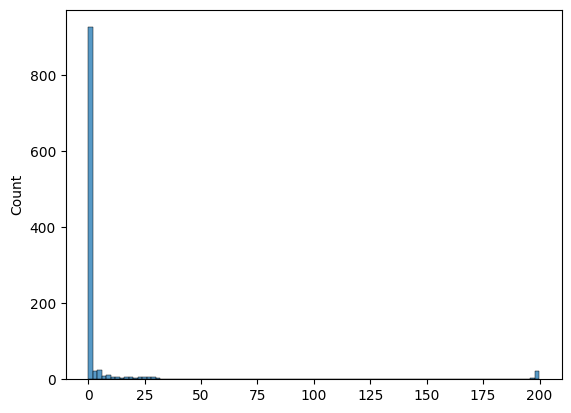

In [54]:
sns.histplot(theta_np, bins = 100)

In [56]:
df.shape

(1094, 28394)

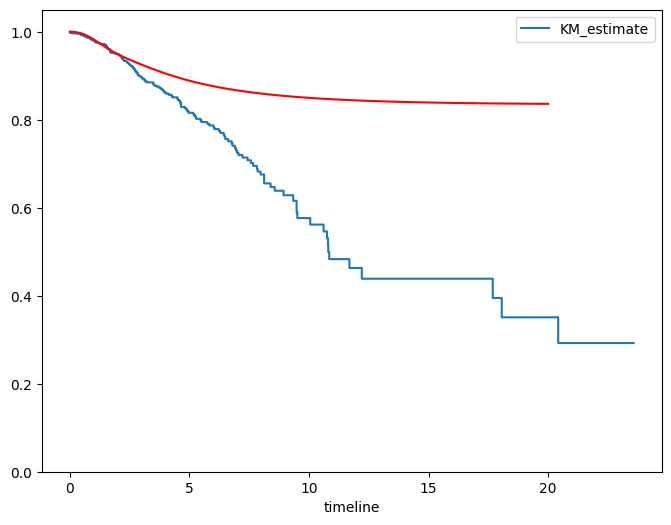

In [55]:
# lam_X = tf.ones_like(lam_X) * 17.15514
# rho_X = 1.299237

ts = tf.constant(np.linspace(0.01, 20, 100), dtype = tf.float32)

F0 = 1 - tf.math.exp( -(ts / lam_X)**rho_X )

S_ts = tf.math.exp( -theta_X * F0 )
S_ts_avg = tf.reduce_mean( S_ts, axis = 0 )

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df["time"]/365, df["delta"])
km.plot(ax = ax, ci_show = False, show_censors = False, censor_styles={
    'ms': 7,      # marker size
    'marker': '+', # marker shape
    'mew': 2,       # marker edge width
    'markeredgecolor': 'black',
    'zorder': 5
})
# sns.lineplot(x = ts, y = S_ts_avg, color = "red")
ax.plot(ts, S_ts_avg, color = "red")

ax.set_ylim(0,1.05)

plt.show()

# tf.print("-> LAST SAFE lam (min | max):", tf.reduce_min(lam_batch), "|", tf.reduce_max(lam_batch))
# tf.print("-> LAST SAFE rho (min | max):", tf.reduce_min(rho_batch), "|", tf.reduce_max(rho_batch))

In [41]:
np.mean(1-delta)

np.float64(0.8610603290676416)